In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Connect to (or create) the SQLite database
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()


In [ ]:
# Create the sales table 
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")


In [4]:
# Sample data
sample_data = [
    ("Apples", 10, 0.5),
    ("Bananas", 20, 0.3),
    ("Oranges", 15, 0.4),
    ("Apples", 5, 0.5),
    ("Bananas", 10, 0.3),
    ("Oranges", 10, 0.4)
]

# Only insert if table is empty
cursor.execute("SELECT COUNT(*) FROM sales")
if cursor.fetchone()[0] == 0:
    cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
    conn.commit()


In [6]:
# SQL query to get total quantity and revenue by product
query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""

# Load into pandas DataFrame
df = pd.read_sql_query(query, conn)
df


,product,total_qty,revenue
0,Apple,15,7.5
1,Banana,25,5.0
2,Grapes,20,20.0
3,Orange,30,9.0


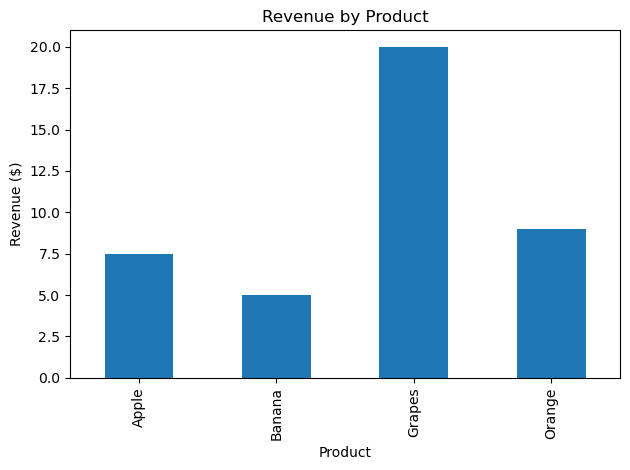

In [7]:
# Plot a bar chart of revenue by product
df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.title("Revenue by Product")
plt.ylabel("Revenue ($)")
plt.xlabel("Product")
plt.tight_layout()
plt.savefig("sales_chart.png")  # Optional: Save chart
plt.show()


In [8]:
# Always good practice to close the DB connection
conn.close()
